# MALLORN Astronomical Classification Challenge — v3

**Goal**: Identify Tidal Disruption Events (TDEs) from simulated LSST light curves.

**Metric**: F1 Score (binary classification)

**v3 Strategy** (vs v2 which scored 0.5539 Public):
1. **Feature Selection** — reduce from 267 → ~60 top features (remove noise)
2. **Optuna Hyperparameter Tuning** — Bayesian optimization for LGB/XGB/CatBoost
3. **Pseudo-Labeling** — iterative self-training with high-confidence test predictions
4. **Robust Threshold** — nested CV threshold to avoid overfitting
5. **Focused Ensemble** — only LightGBM + XGBoost + CatBoost (drop weak ExtraTrees/BRF)

## 1. Setup & Imports

In [1]:
!pip install catboost imbalanced-learn optuna -q

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

DATA_DIR = "/Users/jackietan/Documents/workshop/academic/csc753m/kaggle_project/mallorn-astronomical-classification-challenge/data"
FILTERS = ["u", "g", "r", "i", "z", "y"]
N_SPLITS = 20
SEED = 42
np.random.seed(SEED)

## 2. Load Data

In [3]:
train_log = pd.read_csv(os.path.join(DATA_DIR, "train_log.csv"))
test_log = pd.read_csv(os.path.join(DATA_DIR, "test_log.csv"))

print(f"Train: {len(train_log)} objects ({train_log['target'].sum()} TDEs, {len(train_log) - train_log['target'].sum()} non-TDEs)")
print(f"Test:  {len(test_log)} objects")
print(f"TDE ratio: {train_log['target'].mean():.2%}")

train_lcs, test_lcs = [], []
for i in tqdm(range(1, N_SPLITS + 1), desc="Loading splits"):
    d = os.path.join(DATA_DIR, f"split_{i:02d}")
    train_lcs.append(pd.read_csv(os.path.join(d, "train_full_lightcurves.csv")))
    test_lcs.append(pd.read_csv(os.path.join(d, "test_full_lightcurves.csv")))

train_lc = pd.concat(train_lcs, ignore_index=True)
test_lc = pd.concat(test_lcs, ignore_index=True)
del train_lcs, test_lcs

print(f"Train LC rows: {len(train_lc):,}")
print(f"Test  LC rows: {len(test_lc):,}")

Train: 3043 objects (148 TDEs, 2895 non-TDEs)
Test:  7135 objects
TDE ratio: 4.86%


Loading splits:   0%|          | 0/20 [00:00<?, ?it/s]

Train LC rows: 479,384
Test  LC rows: 1,145,125


## 3. Feature Engineering (same as v2)

In [4]:
def safe_stat(arr, func, default=0):
    try:
        if len(arr) < 2:
            return default
        val = func(arr)
        return val if np.isfinite(val) else default
    except Exception:
        return default


def compute_weighted_mean(flux, flux_err):
    w = 1.0 / (flux_err**2 + 1e-10)
    return np.sum(flux * w) / np.sum(w)


def compute_stetson_j(flux, flux_err):
    if len(flux) < 3:
        return 0
    mean = compute_weighted_mean(flux, flux_err)
    residuals = (flux - mean) / (flux_err + 1e-10)
    n = len(flux)
    pairs = residuals[:-1] * residuals[1:]
    sign_pairs = np.sign(pairs)
    return np.sum(sign_pairs * np.sqrt(np.abs(pairs))) / n


def compute_stetson_k(flux, flux_err):
    if len(flux) < 3:
        return 0
    mean = compute_weighted_mean(flux, flux_err)
    residuals = (flux - mean) / (flux_err + 1e-10)
    n = len(flux)
    return np.sum(np.abs(residuals)) / (n * np.sqrt(np.sum(residuals**2) / n) + 1e-10)


def compute_von_neumann_ratio(flux):
    if len(flux) < 3:
        return 0
    var = np.var(flux)
    if var < 1e-10:
        return 0
    return np.mean(np.diff(flux)**2) / var


def bazin_func(t, A, t0, t_rise, t_fall, c):
    return A * np.exp(-(t - t0) / t_fall) / (1 + np.exp(-(t - t0) / t_rise)) + c


def fit_bazin(time, flux):
    defaults = {"bazin_A": 0, "bazin_t_rise": 0, "bazin_t_fall": 0,
                "bazin_c": 0, "bazin_rise_fall_ratio": 0, "bazin_fit_residual": 1e6}
    if len(time) < 6:
        return defaults
    try:
        t_norm = time - time[0]
        A0 = np.max(flux) - np.min(flux)
        t0_0 = t_norm[np.argmax(flux)]
        p0 = [A0, t0_0, 20.0, 40.0, np.median(flux)]
        bounds = ([0, 0, 0.1, 0.1, -np.inf], [np.inf, t_norm[-1] * 2, 500, 500, np.inf])
        popt, _ = curve_fit(bazin_func, t_norm, flux, p0=p0, bounds=bounds,
                           maxfev=1000, method='trf')
        A, t0, t_rise, t_fall, c = popt
        residual = np.mean((flux - bazin_func(t_norm, *popt))**2)
        return {"bazin_A": A, "bazin_t_rise": t_rise, "bazin_t_fall": t_fall,
                "bazin_c": c, "bazin_rise_fall_ratio": t_rise / (t_fall + 1e-10),
                "bazin_fit_residual": residual}
    except Exception:
        return defaults


def compute_structure_function(time, flux, lags=[5, 20, 50, 100]):
    feats = {}
    if len(time) < 3:
        for lag in lags:
            feats[f"sf_lag{lag}"] = 0
        return feats
    for lag in lags:
        diffs = []
        for i in range(len(time)):
            for j in range(i + 1, min(i + 50, len(time))):
                dt = abs(time[j] - time[i])
                if lag * 0.5 <= dt <= lag * 1.5:
                    diffs.append((flux[j] - flux[i])**2)
        feats[f"sf_lag{lag}"] = np.mean(diffs) if diffs else 0
    return feats


def compute_autocorrelation(flux, lags=[1, 2, 5, 10]):
    feats = {}
    n = len(flux)
    if n < 12:
        for lag in lags:
            feats[f"autocorr_lag{lag}"] = 0
        return feats
    mean = np.mean(flux)
    var = np.var(flux)
    if var < 1e-10:
        for lag in lags:
            feats[f"autocorr_lag{lag}"] = 0
        return feats
    for lag in lags:
        if lag >= n:
            feats[f"autocorr_lag{lag}"] = 0
        else:
            c = np.mean((flux[:n-lag] - mean) * (flux[lag:] - mean)) / var
            feats[f"autocorr_lag{lag}"] = c if np.isfinite(c) else 0
    return feats

In [5]:
def extract_features_v2(group):
    """Extract all features from one object's light curve — v2 enhanced."""
    feats = {}
    flux = group["Flux"].values
    flux_err = group["Flux_err"].values
    time = group["Time (MJD)"].values
    filters = group["Filter"].values

    sort_idx = np.argsort(time)
    flux_s = flux[sort_idx]
    time_s = time[sort_idx]
    flux_err_s = flux_err[sort_idx]
    filters_s = filters[sort_idx]
    n = len(flux)

    # ========== Global basic stats ==========
    feats["n_obs"] = n
    feats["flux_mean"] = np.mean(flux)
    feats["flux_std"] = np.std(flux) if n > 1 else 0
    feats["flux_median"] = np.median(flux)
    feats["flux_min"] = np.min(flux)
    feats["flux_max"] = np.max(flux)
    feats["flux_range"] = feats["flux_max"] - feats["flux_min"]
    feats["flux_skew"] = safe_stat(flux, stats.skew)
    feats["flux_kurtosis"] = safe_stat(flux, stats.kurtosis)
    feats["flux_iqr"] = np.percentile(flux, 75) - np.percentile(flux, 25)
    feats["flux_p5"] = np.percentile(flux, 5)
    feats["flux_p10"] = np.percentile(flux, 10)
    feats["flux_p25"] = np.percentile(flux, 25)
    feats["flux_p75"] = np.percentile(flux, 75)
    feats["flux_p90"] = np.percentile(flux, 90)
    feats["flux_p95"] = np.percentile(flux, 95)
    feats["flux_above_mean_frac"] = np.mean(flux > feats["flux_mean"])
    feats["flux_positive_frac"] = np.mean(flux > 0)
    feats["flux_mad"] = np.median(np.abs(flux - feats["flux_median"]))
    feats["flux_wmean"] = compute_weighted_mean(flux, flux_err)
    feats["flux_cv"] = feats["flux_std"] / (abs(feats["flux_mean"]) + 1e-10)

    # ========== Flux asymmetry ==========
    above = flux[flux > feats["flux_median"]]
    below = flux[flux <= feats["flux_median"]]
    feats["flux_asymmetry"] = (np.mean(above) - abs(np.mean(below))) / (feats["flux_range"] + 1e-10) if len(above) > 0 and len(below) > 0 else 0
    feats["flux_above_std"] = np.std(above) if len(above) > 1 else 0
    feats["flux_below_std"] = np.std(below) if len(below) > 1 else 0
    feats["flux_std_ratio"] = feats["flux_above_std"] / (feats["flux_below_std"] + 1e-10)

    # ========== Error features ==========
    feats["flux_err_mean"] = np.mean(flux_err)
    feats["flux_err_std"] = np.std(flux_err) if n > 1 else 0
    feats["flux_err_median"] = np.median(flux_err)
    snr = np.abs(flux) / (flux_err + 1e-10)
    feats["snr_mean"] = np.mean(snr)
    feats["snr_max"] = np.max(snr)
    feats["snr_std"] = np.std(snr) if n > 1 else 0
    feats["snr_median"] = np.median(snr)
    feats["high_snr_frac"] = np.mean(snr > 3)

    # ========== Time features ==========
    feats["time_span"] = np.ptp(time_s) if n > 1 else 0
    feats["n_unique_nights"] = len(np.unique(np.round(time_s)))

    if n > 1:
        dt = np.diff(time_s)
        feats["dt_mean"] = np.mean(dt)
        feats["dt_std"] = np.std(dt)
        feats["dt_min"] = np.min(dt)
        feats["dt_max"] = np.max(dt)
        feats["dt_median"] = np.median(dt)
        dflux = np.diff(flux_s)
        rates = dflux / (dt + 1e-10)
        feats["flux_rate_mean"] = np.mean(rates)
        feats["flux_rate_std"] = np.std(rates)
        feats["flux_rate_max"] = np.max(rates)
        feats["flux_rate_min"] = np.min(rates)
        feats["flux_rate_abs_max"] = np.max(np.abs(rates))
        feats["flux_rate_pos_frac"] = np.mean(rates > 0)
        feats["flux_rate_skew"] = safe_stat(rates, stats.skew)
        feats["flux_rate_kurtosis"] = safe_stat(rates, stats.kurtosis)
    else:
        for k in ["dt_mean", "dt_std", "dt_min", "dt_max", "dt_median",
                   "flux_rate_mean", "flux_rate_std", "flux_rate_max",
                   "flux_rate_min", "flux_rate_abs_max", "flux_rate_pos_frac",
                   "flux_rate_skew", "flux_rate_kurtosis"]:
            feats[k] = 0

    # ========== Peak analysis ==========
    peak_idx = np.argmax(flux_s)
    feats["peak_flux"] = flux_s[peak_idx]
    feats["peak_phase"] = (time_s[peak_idx] - time_s[0]) / (feats["time_span"] + 1e-10) if n > 1 else 0.5
    feats["peak_time_from_start"] = time_s[peak_idx] - time_s[0]

    if peak_idx > 0:
        rise_flux = flux_s[:peak_idx + 1]
        rise_time = time_s[:peak_idx + 1]
        feats["rise_rate"] = (rise_flux[-1] - rise_flux[0]) / (rise_time[-1] - rise_time[0] + 1e-10)
        feats["rise_duration"] = rise_time[-1] - rise_time[0]
        feats["rise_n_obs"] = len(rise_flux)
    else:
        feats["rise_rate"] = 0
        feats["rise_duration"] = 0
        feats["rise_n_obs"] = 0

    if peak_idx < n - 1:
        dec_flux = flux_s[peak_idx:]
        dec_time = time_s[peak_idx:]
        feats["decline_rate"] = (dec_flux[-1] - dec_flux[0]) / (dec_time[-1] - dec_time[0] + 1e-10)
        feats["decline_duration"] = dec_time[-1] - dec_time[0]
        feats["decline_n_obs"] = len(dec_flux)
    else:
        feats["decline_rate"] = 0
        feats["decline_duration"] = 0
        feats["decline_n_obs"] = 0

    feats["rise_decline_ratio"] = feats["rise_duration"] / (feats["decline_duration"] + 1e-10)
    feats["amplitude_snr"] = feats["flux_range"] / (feats["flux_err_mean"] + 1e-10)
    feats["rise_rate_abs"] = abs(feats["rise_rate"])
    feats["decline_rate_abs"] = abs(feats["decline_rate"])
    feats["rise_decline_rate_ratio"] = feats["rise_rate_abs"] / (feats["decline_rate_abs"] + 1e-10)

    # ========== Variability indices ==========
    feats["stetson_j"] = compute_stetson_j(flux_s, flux_err_s)
    feats["stetson_k"] = compute_stetson_k(flux_s, flux_err_s)
    feats["von_neumann"] = compute_von_neumann_ratio(flux_s)
    mean_err_sq = np.mean(flux_err**2)
    feats["excess_variance"] = (np.var(flux) - mean_err_sq) / (feats["flux_mean"]**2 + 1e-10)
    w = 1.0 / (flux_err**2 + 1e-10)
    wmean = feats["flux_wmean"]
    feats["flux_wstd"] = np.sqrt(np.sum(w * (flux - wmean)**2) / np.sum(w)) if n > 1 else 0

    if n > 5:
        try:
            peaks, _ = find_peaks(flux_s, height=feats["flux_mean"])
            feats["n_peaks"] = len(peaks)
            peaks_low, _ = find_peaks(-flux_s, height=-feats["flux_mean"])
            feats["n_dips"] = len(peaks_low)
        except Exception:
            feats["n_peaks"] = 0
            feats["n_dips"] = 0
    else:
        feats["n_peaks"] = 0
        feats["n_dips"] = 0

    # ========== Bazin function fit ==========
    bazin_feats = fit_bazin(time_s, flux_s)
    feats.update(bazin_feats)

    # ========== Structure function ==========
    sf_feats = compute_structure_function(time_s, flux_s)
    feats.update(sf_feats)

    # ========== Autocorrelation ==========
    ac_feats = compute_autocorrelation(flux_s)
    feats.update(ac_feats)

    # ========== Rolling statistics ==========
    if n >= 10:
        w_size = max(n // 5, 5)
        rolling_means = [np.mean(flux_s[i:i+w_size]) for i in range(0, n - w_size + 1, w_size // 2)]
        rolling_stds = [np.std(flux_s[i:i+w_size]) for i in range(0, n - w_size + 1, w_size // 2)]
        feats["rolling_mean_std"] = np.std(rolling_means) if len(rolling_means) > 1 else 0
        feats["rolling_mean_range"] = np.ptp(rolling_means) if rolling_means else 0
        feats["rolling_std_mean"] = np.mean(rolling_stds) if rolling_stds else 0
        feats["rolling_std_max"] = np.max(rolling_stds) if rolling_stds else 0
    else:
        feats["rolling_mean_std"] = 0
        feats["rolling_mean_range"] = 0
        feats["rolling_std_mean"] = 0
        feats["rolling_std_max"] = 0

    # ========== Consecutive increase/decrease runs ==========
    if n > 2:
        diffs = np.diff(flux_s)
        signs = np.sign(diffs)
        max_inc = max_dec = cur_inc = cur_dec = 0
        for s in signs:
            if s > 0:
                cur_inc += 1
                cur_dec = 0
            elif s < 0:
                cur_dec += 1
                cur_inc = 0
            else:
                cur_inc = 0
                cur_dec = 0
            max_inc = max(max_inc, cur_inc)
            max_dec = max(max_dec, cur_dec)
        feats["max_consecutive_increase"] = max_inc
        feats["max_consecutive_decrease"] = max_dec
    else:
        feats["max_consecutive_increase"] = 0
        feats["max_consecutive_decrease"] = 0

    # ========== Per-filter features ==========
    band_means = {}
    band_stds = {}
    band_peak_flux = {}
    band_peak_times = {}
    for filt in FILTERS:
        mask = filters == filt
        f_flux = flux[mask]
        f_err = flux_err[mask]
        f_time = time[mask]
        prefix = f"f_{filt}_"
        feats[prefix + "n"] = len(f_flux)

        if len(f_flux) > 0:
            feats[prefix + "mean"] = np.mean(f_flux)
            feats[prefix + "std"] = np.std(f_flux) if len(f_flux) > 1 else 0
            feats[prefix + "max"] = np.max(f_flux)
            feats[prefix + "min"] = np.min(f_flux)
            feats[prefix + "range"] = feats[prefix + "max"] - feats[prefix + "min"]
            feats[prefix + "skew"] = safe_stat(f_flux, stats.skew)
            feats[prefix + "kurtosis"] = safe_stat(f_flux, stats.kurtosis)
            feats[prefix + "snr"] = np.mean(np.abs(f_flux) / (f_err + 1e-10))
            feats[prefix + "wmean"] = compute_weighted_mean(f_flux, f_err)
            feats[prefix + "mad"] = np.median(np.abs(f_flux - np.median(f_flux)))
            feats[prefix + "p10"] = np.percentile(f_flux, 10)
            feats[prefix + "p90"] = np.percentile(f_flux, 90)
            feats[prefix + "positive_frac"] = np.mean(f_flux > 0)
            feats[prefix + "cv"] = feats[prefix + "std"] / (abs(feats[prefix + "mean"]) + 1e-10)
            band_means[filt] = feats[prefix + "mean"]
            band_stds[filt] = feats[prefix + "std"]
            band_peak_flux[filt] = feats[prefix + "max"]

            if len(f_flux) > 2:
                si = np.argsort(f_time)
                fs = f_flux[si]
                ts = f_time[si]
                dt_f = np.diff(ts)
                df_f = np.diff(fs)
                rates_f = df_f / (dt_f + 1e-10)
                feats[prefix + "rate_max"] = np.max(np.abs(rates_f))
                feats[prefix + "rate_mean"] = np.mean(rates_f)
                pk = np.argmax(fs)
                feats[prefix + "peak_phase"] = (ts[pk] - ts[0]) / (ts[-1] - ts[0] + 1e-10)
                feats[prefix + "stetson_j"] = compute_stetson_j(f_flux[si], f_err[si])
                feats[prefix + "von_neumann"] = compute_von_neumann_ratio(fs)
                band_peak_times[filt] = ts[pk]
            else:
                feats[prefix + "rate_max"] = 0
                feats[prefix + "rate_mean"] = 0
                feats[prefix + "peak_phase"] = 0.5
                feats[prefix + "stetson_j"] = 0
                feats[prefix + "von_neumann"] = 0
                band_peak_times[filt] = np.nan
        else:
            for sfx in ["mean", "std", "max", "min", "range", "skew", "kurtosis",
                         "snr", "wmean", "mad", "p10", "p90", "positive_frac", "cv",
                         "rate_max", "rate_mean", "peak_phase", "stetson_j", "von_neumann"]:
                feats[prefix + sfx] = 0
            band_means[filt] = 0
            band_stds[filt] = 0
            band_peak_flux[filt] = 0
            band_peak_times[filt] = np.nan

    # ========== Color features ==========
    color_pairs = [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z"), ("z", "y"),
                   ("g", "i"), ("u", "r"), ("r", "z"), ("u", "i"), ("g", "z")]
    for b1, b2 in color_pairs:
        feats[f"color_{b1}_{b2}"] = band_means[b1] - band_means[b2]
        feats[f"color_peak_{b1}_{b2}"] = band_peak_flux[b1] - band_peak_flux[b2]
        feats[f"color_ratio_{b1}_{b2}"] = band_means[b1] / (band_means[b2] + 1e-10) if band_means[b2] != 0 else 0

    feats["color_g_r_range"] = feats.get("f_g_range", 0) - feats.get("f_r_range", 0)
    feats["color_r_i_range"] = feats.get("f_r_range", 0) - feats.get("f_i_range", 0)

    # ========== Cross-filter peak timing ==========
    for b1, b2 in [("g", "r"), ("r", "i"), ("i", "z"), ("u", "g"), ("z", "y")]:
        t1 = band_peak_times.get(b1, np.nan)
        t2 = band_peak_times.get(b2, np.nan)
        if not np.isnan(t1) and not np.isnan(t2):
            feats[f"peak_delay_{b1}_{b2}"] = t1 - t2
        else:
            feats[f"peak_delay_{b1}_{b2}"] = 0

    # ========== Cross-filter variability ratio ==========
    for b1, b2 in [("g", "r"), ("r", "i"), ("g", "i")]:
        feats[f"var_ratio_{b1}_{b2}"] = band_stds[b1] / (band_stds[b2] + 1e-10)

    return feats


def build_features(lc_df, meta_df, desc="Features"):
    grouped = lc_df.groupby("object_id")
    records = []
    for obj_id, group in tqdm(grouped, desc=desc):
        feats = extract_features_v2(group)
        feats["object_id"] = obj_id
        records.append(feats)

    feat_df = pd.DataFrame(records)
    merged = meta_df.merge(feat_df, on="object_id", how="left")

    merged["Z"] = pd.to_numeric(merged["Z"], errors="coerce")
    merged["Z_err"] = pd.to_numeric(merged["Z_err"], errors="coerce")
    merged["EBV"] = pd.to_numeric(merged["EBV"], errors="coerce")

    merged["flux_mean_over_z"] = merged["flux_mean"] / (merged["Z"] + 1e-10)
    merged["flux_range_over_z"] = merged["flux_range"] / (merged["Z"] + 1e-10)
    merged["amplitude_over_z"] = merged["amplitude_snr"] / (merged["Z"] + 1e-10)
    merged["peak_flux_over_z"] = merged["peak_flux"] / (merged["Z"] + 1e-10)
    merged["stetson_j_over_z"] = merged["stetson_j"] / (merged["Z"] + 1e-10)
    merged["Z_times_EBV"] = merged["Z"] * merged["EBV"]
    merged["Z_squared"] = merged["Z"] ** 2
    merged["log_flux_range"] = np.log1p(np.abs(merged["flux_range"]))
    merged["log_peak_flux"] = np.log1p(np.abs(merged["peak_flux"]))
    merged["log_flux_std"] = np.log1p(np.abs(merged["flux_std"]))
    merged["has_z_err"] = (~merged["Z_err"].isna()).astype(int)
    merged["rise_rate_over_z"] = merged["rise_rate"] / (merged["Z"] + 1e-10)
    merged["decline_rate_over_z"] = merged["decline_rate"] / (merged["Z"] + 1e-10)
    merged["flux_mean_ebv_corr"] = merged["flux_mean"] / (1 + merged["EBV"])
    merged["flux_range_ebv_corr"] = merged["flux_range"] / (1 + merged["EBV"])

    return merged

In [6]:
print("Building train features...")
train_feat = build_features(train_lc, train_log, desc="Train features")
print(f"\nBuilding test features...")
test_feat = build_features(test_lc, test_log, desc="Test features")

print(f"\nTrain shape: {train_feat.shape}")
print(f"Test shape:  {test_feat.shape}")

Building train features...


Train features:   0%|          | 0/3043 [00:00<?, ?it/s]


Building test features...


Test features:   0%|          | 0/7135 [00:00<?, ?it/s]


Train shape: (3043, 272)
Test shape:  (7135, 271)


## 4. Prepare Data & Feature Selection

v2 had 267 features — many are noise. We use LightGBM importance to select the top ~60 features, reducing overfitting risk.

In [7]:
exclude = {"object_id", "SpecType", "English Translation", "split", "target"}
all_feature_cols = [c for c in train_feat.columns if c not in exclude
                    and train_feat[c].dtype in [np.float64, np.int64, float, int]]

X_all = train_feat[all_feature_cols].values.astype(np.float32)
y = train_feat["target"].values.astype(int)
X_test_all = test_feat[all_feature_cols].values.astype(np.float32)

X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
X_test_all = np.nan_to_num(X_test_all, nan=0.0, posinf=0.0, neginf=0.0)

neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos = neg / max(pos, 1)

print(f"All features: {len(all_feature_cols)}")
print(f"Class ratio: {neg}:{pos} (scale_pos_weight={scale_pos:.1f})")

# --- Feature selection via multi-seed LightGBM importance ---
TOP_K = 60
importance_acc = np.zeros(len(all_feature_cols))

for seed in [42, 123, 456]:
    lgb_sel = lgb.LGBMClassifier(
        objective="binary", n_estimators=1500, learning_rate=0.01,
        num_leaves=24, max_depth=6, min_child_samples=5,
        scale_pos_weight=scale_pos, subsample=0.7, colsample_bytree=0.7,
        reg_alpha=1.0, reg_lambda=3.0, verbose=-1, n_jobs=-1, random_state=seed,
    )
    lgb_sel.fit(X_all, y)
    importance_acc += lgb_sel.feature_importances_

importance_df = pd.DataFrame({
    "feature": all_feature_cols,
    "importance": importance_acc,
}).sort_values("importance", ascending=False)

selected_features = importance_df.head(TOP_K)["feature"].tolist()
print(f"\nSelected top {TOP_K} features:")
print(importance_df.head(TOP_K)[["feature", "importance"]].to_string(index=False))

# Build reduced feature matrices
feature_cols = selected_features
feat_idx = [all_feature_cols.index(f) for f in feature_cols]
X = X_all[:, feat_idx]
X_test = X_test_all[:, feat_idx]
print(f"\nReduced feature matrix: {X.shape}")

All features: 267
Class ratio: 2895:148 (scale_pos_weight=19.6)

Selected top 60 features:
              feature  importance
   bazin_fit_residual      1405.0
           snr_median      1350.0
       peak_delay_g_r      1194.0
bazin_rise_fall_ratio      1139.0
             f_g_skew      1116.0
                    Z      1051.0
       peak_delay_r_i      1040.0
              sf_lag5      1026.0
         f_g_rate_max      1026.0
             f_r_skew      1011.0
         bazin_t_fall      1003.0
         bazin_t_rise       920.0
              f_r_mad       916.0
            time_span       907.0
      f_g_von_neumann       887.0
 flux_above_mean_frac       880.0
       color_peak_u_g       880.0
              f_r_p10       823.0
       peak_delay_u_g       787.0
       f_z_peak_phase       767.0
        flux_err_mean       748.0
               f_u_cv       725.0
         f_r_rate_max       696.0
               f_r_cv       690.0
        flux_rate_std       688.0
         f_r_kurtosis    

## 5. Optuna Hyperparameter Tuning

Bayesian optimization for LightGBM, XGBoost, and CatBoost. Each model gets 50 trials with 5-fold CV F1 as the objective.

In [8]:
def cv_f1_score(y_true, y_prob):
    """Find best F1 over thresholds."""
    best_f1 = 0
    for t in np.arange(0.1, 0.9, 0.02):
        best_f1 = max(best_f1, f1_score(y_true, (y_prob >= t).astype(int)))
    return best_f1


def optuna_cv_eval(X, y, model_fn, n_folds=5):
    """Run CV and return mean F1."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    smote = SMOTE(random_state=SEED, k_neighbors=3)
    oof = np.zeros(len(y))
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        try:
            X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
        except Exception:
            pass
        oof[val_idx] = model_fn(X_tr, y_tr, X_val, y_val)
    return cv_f1_score(y, oof)


# ============ LightGBM Optuna ============
def lgb_objective(trial):
    def model_fn(X_tr, y_tr, X_val, y_val):
        params = {
            "objective": "binary", "metric": "binary_logloss", "verbose": -1, "n_jobs": -1,
            "random_state": SEED,
            "learning_rate": trial.suggest_float("lr", 0.005, 0.05, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 12, 48),
            "max_depth": trial.suggest_int("max_depth", 4, 8),
            "min_child_samples": trial.suggest_int("min_child_samples", 3, 20),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5, 40),
            "subsample": trial.suggest_float("subsample", 0.5, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.9),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 10, log=True),
        }
        dtrain = lgb.Dataset(X_tr, y_tr)
        dval = lgb.Dataset(X_val, y_val, reference=dtrain)
        model = lgb.train(params, dtrain, num_boost_round=5000,
                         valid_sets=[dval], callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
        return model.predict(X_val)
    return optuna_cv_eval(X, y, model_fn)

print("Tuning LightGBM (50 trials)...")
lgb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print(f"Best LGB F1: {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

Tuning LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1931]	valid_0's binary_logloss: 0.166667
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1935]	valid_0's binary_logloss: 0.12605
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2020]	valid_0's binary_logloss: 0.129775
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1877]	valid_0's binary_logloss: 0.151379
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1892]	valid_0's binary_logloss: 0.144246
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[818]	valid_0's binary_logloss: 0.160826
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1490]	valid_0's binary_logloss: 0.125359
Training until validation sco

In [9]:
# ============ XGBoost Optuna ============
def xgb_objective(trial):
    def model_fn(X_tr, y_tr, X_val, y_val):
        params = {
            "objective": "binary:logistic", "eval_metric": "logloss", "verbosity": 0,
            "nthread": -1, "random_state": SEED,
            "learning_rate": trial.suggest_float("lr", 0.005, 0.05, log=True),
            "max_depth": trial.suggest_int("max_depth", 4, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 3, 20),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5, 40),
            "subsample": trial.suggest_float("subsample", 0.5, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.9),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 10, log=True),
            "gamma": trial.suggest_float("gamma", 0, 5),
        }
        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)
        model = xgb.train(params, dtrain, num_boost_round=5000,
                         evals=[(dval, "val")], early_stopping_rounds=200, verbose_eval=False)
        return model.predict(dval)
    return optuna_cv_eval(X, y, model_fn)

print("Tuning XGBoost (50 trials)...")
xgb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print(f"Best XGB F1: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

Tuning XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best XGB F1: 0.6177
Best params: {'lr': 0.03563289276808638, 'max_depth': 4, 'min_child_weight': 4, 'scale_pos_weight': 39.9584048157333, 'subsample': 0.8180036728491121, 'colsample_bytree': 0.5459035591898033, 'reg_alpha': 0.0616319746539033, 'reg_lambda': 5.863002415508457, 'gamma': 0.27760350845766507}


In [10]:
# ============ CatBoost Optuna ============
def cat_objective(trial):
    def model_fn(X_tr, y_tr, X_val, y_val):
        model = CatBoostClassifier(
            iterations=3000, verbose=0, random_seed=SEED, early_stopping_rounds=200,
            eval_metric="Logloss", auto_class_weights="Balanced",
            learning_rate=trial.suggest_float("lr", 0.005, 0.05, log=True),
            depth=trial.suggest_int("depth", 4, 8),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 0.1, 20, log=True),
            random_strength=trial.suggest_float("random_strength", 0.5, 5),
            bagging_temperature=trial.suggest_float("bagging_temperature", 0.1, 3),
            border_count=trial.suggest_int("border_count", 32, 255),
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
        return model.predict_proba(X_val)[:, 1]
    return optuna_cv_eval(X, y, model_fn)

print("Tuning CatBoost (50 trials)...")
cat_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
cat_study.optimize(cat_objective, n_trials=50, show_progress_bar=True)
print(f"Best CatBoost F1: {cat_study.best_value:.4f}")
print(f"Best params: {cat_study.best_params}")

Tuning CatBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best CatBoost F1: 0.6345
Best params: {'lr': 0.00778708533065567, 'depth': 6, 'l2_leaf_reg': 1.1097248759488423, 'random_strength': 4.181464865362936, 'bagging_temperature': 2.300620031245481, 'border_count': 255}


## 6. Model Training — Focused 3-Model Ensemble with Tuned Hyperparameters

Only LightGBM + XGBoost + CatBoost (dropped weak ExtraTrees and BalancedRF from v2).
Using Optuna-tuned hyperparameters and 10-fold CV with SMOTE.

In [11]:
# Build optimized param dicts from Optuna results
best_lgb = lgb_study.best_params
lgb_params = {
    "objective": "binary", "metric": "binary_logloss", "verbose": -1, "n_jobs": -1,
    "random_state": SEED,
    "learning_rate": best_lgb["lr"],
    "num_leaves": best_lgb["num_leaves"],
    "max_depth": best_lgb["max_depth"],
    "min_child_samples": best_lgb["min_child_samples"],
    "scale_pos_weight": best_lgb["scale_pos_weight"],
    "subsample": best_lgb["subsample"],
    "colsample_bytree": best_lgb["colsample_bytree"],
    "reg_alpha": best_lgb["reg_alpha"],
    "reg_lambda": best_lgb["reg_lambda"],
}

best_xgb = xgb_study.best_params
xgb_params = {
    "objective": "binary:logistic", "eval_metric": "logloss", "verbosity": 0,
    "nthread": -1, "random_state": SEED,
    "learning_rate": best_xgb["lr"],
    "max_depth": best_xgb["max_depth"],
    "min_child_weight": best_xgb["min_child_weight"],
    "scale_pos_weight": best_xgb["scale_pos_weight"],
    "subsample": best_xgb["subsample"],
    "colsample_bytree": best_xgb["colsample_bytree"],
    "reg_alpha": best_xgb["reg_alpha"],
    "reg_lambda": best_xgb["reg_lambda"],
    "gamma": best_xgb["gamma"],
}

best_cat = cat_study.best_params
cat_kwargs = {
    "iterations": 3000, "verbose": 0, "random_seed": SEED, "early_stopping_rounds": 200,
    "eval_metric": "Logloss", "auto_class_weights": "Balanced",
    "learning_rate": best_cat["lr"],
    "depth": best_cat["depth"],
    "l2_leaf_reg": best_cat["l2_leaf_reg"],
    "random_strength": best_cat["random_strength"],
    "bagging_temperature": best_cat["bagging_temperature"],
    "border_count": best_cat["border_count"],
}

print("Tuned LGB params:", lgb_params)
print("\nTuned XGB params:", xgb_params)
print("\nTuned CatBoost params:", cat_kwargs)

Tuned LGB params: {'objective': 'binary', 'metric': 'binary_logloss', 'verbose': -1, 'n_jobs': -1, 'random_state': 42, 'learning_rate': 0.019162806747844822, 'num_leaves': 28, 'max_depth': 4, 'min_child_samples': 10, 'scale_pos_weight': 5.203362671078717, 'subsample': 0.8129037650264304, 'colsample_bytree': 0.7426379658804952, 'reg_alpha': 0.6083345983970577, 'reg_lambda': 0.012462681912471543}

Tuned XGB params: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'verbosity': 0, 'nthread': -1, 'random_state': 42, 'learning_rate': 0.03563289276808638, 'max_depth': 4, 'min_child_weight': 4, 'scale_pos_weight': 39.9584048157333, 'subsample': 0.8180036728491121, 'colsample_bytree': 0.5459035591898033, 'reg_alpha': 0.0616319746539033, 'reg_lambda': 5.863002415508457, 'gamma': 0.27760350845766507}

Tuned CatBoost params: {'iterations': 3000, 'verbose': 0, 'random_seed': 42, 'early_stopping_rounds': 200, 'eval_metric': 'Logloss', 'auto_class_weights': 'Balanced', 'learning_rate': 0.00

In [12]:
n_folds = 10
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
N_MODELS = 3
model_names = ["LightGBM", "XGBoost", "CatBoost"]

oof_preds = np.zeros((len(y), N_MODELS))
test_preds = np.zeros((len(X_test), N_MODELS))
fold_scores = []

smote = SMOTE(random_state=SEED, k_neighbors=3)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{n_folds}")
    print(f"{'='*50}")
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    print(f"  Train: {len(y_tr)} ({y_tr.sum()} TDE) | Val: {len(y_val)} ({y_val.sum()} TDE)")

    # SMOTE oversampling on train fold
    try:
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
        print(f"  After SMOTE: {len(y_tr_sm)} ({y_tr_sm.sum()} TDE)")
    except Exception:
        X_tr_sm, y_tr_sm = X_tr, y_tr
        print(f"  SMOTE failed, using original data")

    # --- 1. LightGBM ---
    lgb_train = lgb.Dataset(X_tr_sm, y_tr_sm)
    lgb_val_ds = lgb.Dataset(X_val, y_val, reference=lgb_train)
    lgb_model = lgb.train(
        lgb_params, lgb_train, num_boost_round=5000,
        valid_sets=[lgb_val_ds],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)],
    )
    oof_preds[val_idx, 0] = lgb_model.predict(X_val)
    test_preds[:, 0] += lgb_model.predict(X_test) / n_folds

    # --- 2. XGBoost ---
    xgb_tr = xgb.DMatrix(X_tr_sm, label=y_tr_sm)
    xgb_vl = xgb.DMatrix(X_val, label=y_val)
    xgb_model = xgb.train(
        xgb_params, xgb_tr, num_boost_round=5000,
        evals=[(xgb_vl, "val")], early_stopping_rounds=200, verbose_eval=False,
    )
    oof_preds[val_idx, 1] = xgb_model.predict(xgb.DMatrix(X_val))
    test_preds[:, 1] += xgb_model.predict(xgb.DMatrix(X_test)) / n_folds

    # --- 3. CatBoost ---
    cat_model = CatBoostClassifier(**cat_kwargs)
    cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
    oof_preds[val_idx, 2] = cat_model.predict_proba(X_val)[:, 1]
    test_preds[:, 2] += cat_model.predict_proba(X_test)[:, 1] / n_folds

    # Fold score preview (simple average)
    fold_avg = np.mean(oof_preds[val_idx], axis=1)
    best_f1 = max(
        f1_score(y_val, (fold_avg >= t).astype(int))
        for t in np.arange(0.05, 0.9, 0.01)
    )
    fold_scores.append(best_f1)
    print(f"  Fold F1 (avg ensemble): {best_f1:.4f}")

print(f"\nCV Mean F1 (simple avg): {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")


Fold 1/10
  Train: 2738 (133 TDE) | Val: 305 (15 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1026]	valid_0's binary_logloss: 0.171335
  Fold F1 (avg ensemble): 0.5385

Fold 2/10
  Train: 2738 (133 TDE) | Val: 305 (15 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[965]	valid_0's binary_logloss: 0.126896
  Fold F1 (avg ensemble): 0.6500

Fold 3/10
  Train: 2738 (133 TDE) | Val: 305 (15 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1501]	valid_0's binary_logloss: 0.0842014
  Fold F1 (avg ensemble): 0.6957

Fold 4/10
  Train: 2739 (134 TDE) | Val: 304 (14 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1622]	valid_0's binary_logloss: 0.138273
 

## 7. Pseudo-Labeling (Iterative Self-Training)

Use high-confidence test predictions to augment the training set, then retrain.
- Round 1: threshold ≥ 0.90 for positives, ≤ 0.05 for negatives
- Round 2: threshold ≥ 0.85 for positives, ≤ 0.08 for negatives

In [13]:
def pseudo_label_retrain(X_train, y_train, X_test, test_preds_avg,
                         pos_thr=0.90, neg_thr=0.05, round_name="PL"):
    """Add high-confidence pseudo-labels and retrain all 3 models."""
    # Select high-confidence samples
    pos_mask = test_preds_avg >= pos_thr
    neg_mask = test_preds_avg <= neg_thr
    n_pos = pos_mask.sum()
    n_neg = neg_mask.sum()
    print(f"  {round_name}: {n_pos} pseudo-positives (>={pos_thr}), {n_neg} pseudo-negatives (<={neg_thr})")

    if n_pos == 0:
        print(f"  {round_name}: No pseudo-positives found, skipping.")
        return None, None, None

    # Augment training data
    X_pseudo = np.vstack([X_test[pos_mask], X_test[neg_mask]])
    y_pseudo = np.concatenate([np.ones(n_pos), np.zeros(n_neg)])
    X_aug = np.vstack([X_train, X_pseudo])
    y_aug = np.concatenate([y_train, y_pseudo])
    print(f"  {round_name}: Augmented training set: {len(y_aug)} ({int(y_aug.sum())} TDE)")

    # Retrain with 10-fold CV
    n_folds = 10
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED + 100)
    smote = SMOTE(random_state=SEED, k_neighbors=3)

    oof = np.zeros((len(y_train), N_MODELS))  # OOF only for original training data
    test_p = np.zeros((len(X_test), N_MODELS))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_aug, y_aug)):
        X_tr, y_tr = X_aug[tr_idx], y_aug[tr_idx]
        try:
            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
        except Exception:
            X_tr_sm, y_tr_sm = X_tr, y_tr

        # For OOF: only score original training samples that land in val
        orig_val_mask = val_idx < len(y_train)
        orig_val_idx = val_idx[orig_val_mask]
        X_val_orig = X_aug[orig_val_idx] if len(orig_val_idx) > 0 else None

        # LightGBM
        dtrain = lgb.Dataset(X_tr_sm, y_tr_sm)
        model = lgb.train(lgb_params, dtrain, num_boost_round=3000,
                         callbacks=[lgb.log_evaluation(0)])
        test_p[:, 0] += model.predict(X_test) / n_folds
        if X_val_orig is not None and len(orig_val_idx) > 0:
            oof[orig_val_idx, 0] = model.predict(X_val_orig)

        # XGBoost
        xgb_tr = xgb.DMatrix(X_tr_sm, label=y_tr_sm)
        model = xgb.train(xgb_params, xgb_tr, num_boost_round=3000, verbose_eval=False)
        test_p[:, 1] += model.predict(xgb.DMatrix(X_test)) / n_folds
        if X_val_orig is not None and len(orig_val_idx) > 0:
            oof[orig_val_idx, 1] = model.predict(xgb.DMatrix(X_val_orig))

        # CatBoost
        model = CatBoostClassifier(**{**cat_kwargs, "early_stopping_rounds": None})
        model.fit(X_tr, y_tr, verbose=0)
        test_p[:, 2] += model.predict_proba(X_test)[:, 1] / n_folds
        if X_val_orig is not None and len(orig_val_idx) > 0:
            oof[orig_val_idx, 2] = model.predict_proba(X_val_orig)[:, 1]

    oof_avg = np.mean(oof, axis=1)
    test_avg = np.mean(test_p, axis=1)
    f1 = cv_f1_score(y_train, oof_avg)
    print(f"  {round_name}: OOF F1 = {f1:.4f}")
    return oof, test_p, test_avg


# Initial ensemble average from base training
test_avg_base = np.mean(test_preds, axis=1)
oof_avg_base = np.mean(oof_preds, axis=1)

# --- Pseudo-label Round 1 ---
print("Pseudo-label Round 1:")
pl1_oof, pl1_test_preds, pl1_test_avg = pseudo_label_retrain(
    X, y, X_test, test_avg_base, pos_thr=0.90, neg_thr=0.05, round_name="PL-R1"
)

# --- Pseudo-label Round 2 (if Round 1 succeeded) ---
if pl1_test_avg is not None:
    print("\nPseudo-label Round 2:")
    pl2_oof, pl2_test_preds, pl2_test_avg = pseudo_label_retrain(
        X, y, X_test, pl1_test_avg, pos_thr=0.85, neg_thr=0.08, round_name="PL-R2"
    )
else:
    pl2_oof = pl2_test_preds = pl2_test_avg = None

Pseudo-label Round 1:
  PL-R1: 114 pseudo-positives (>=0.9), 4524 pseudo-negatives (<=0.05)
  PL-R1: Augmented training set: 7681 (262 TDE)
  PL-R1: OOF F1 = 0.6441

Pseudo-label Round 2:
  PL-R2: 261 pseudo-positives (>=0.85), 6203 pseudo-negatives (<=0.08)
  PL-R2: Augmented training set: 9507 (409 TDE)
  PL-R2: OOF F1 = 0.6624


## 8. Robust Threshold Selection

Compare base ensemble vs pseudo-label rounds. Use nested CV threshold to avoid overfitting.

In [14]:
def find_best_threshold(y_true, y_prob, method_name=""):
    """Find optimal threshold for F1 score."""
    thresholds = np.arange(0.05, 0.85, 0.005)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1s)
    best_thr = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    print(f"{method_name}: Best F1={best_f1:.4f} at threshold={best_thr:.3f}")
    return best_thr, best_f1, thresholds, f1s


def nested_cv_threshold(y_true, y_prob, method_name=""):
    """Find threshold via nested CV to avoid overfitting the threshold to OOF."""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 42)
    thresholds_found = []
    for tr_idx, val_idx in skf.split(y_prob.reshape(-1, 1), y_true):
        # Find best threshold on inner fold
        best_t, best_f = 0.5, 0
        for t in np.arange(0.1, 0.8, 0.01):
            f = f1_score(y_true[tr_idx], (y_prob[tr_idx] >= t).astype(int))
            if f > best_f:
                best_f = f
                best_t = t
        thresholds_found.append(best_t)
    robust_thr = np.median(thresholds_found)
    robust_f1 = f1_score(y_true, (y_prob >= robust_thr).astype(int))
    print(f"{method_name} (nested CV): F1={robust_f1:.4f} at threshold={robust_thr:.3f} (thresholds: {[f'{t:.3f}' for t in thresholds_found]})")
    return robust_thr, robust_f1


# Collect all candidates
candidates = []

# Base ensemble
oof_base = np.mean(oof_preds, axis=1)
test_base = np.mean(test_preds, axis=1)
thr_b, f1_b, _, _ = find_best_threshold(y, oof_base, "Base ensemble")
thr_b_ncv, f1_b_ncv = nested_cv_threshold(y, oof_base, "Base ensemble")
candidates.append(("base", f1_b, thr_b, oof_base, test_base))
candidates.append(("base_ncv", f1_b_ncv, thr_b_ncv, oof_base, test_base))

# Per-model
for i, name in enumerate(model_names):
    thr, f1_val, _, _ = find_best_threshold(y, oof_preds[:, i], name)
    candidates.append((name, f1_val, thr, oof_preds[:, i], test_preds[:, i]))

# Pseudo-label rounds
if pl1_oof is not None:
    pl1_avg = np.mean(pl1_oof, axis=1)
    thr_pl1, f1_pl1, _, _ = find_best_threshold(y, pl1_avg, "PL Round 1")
    candidates.append(("PL_R1", f1_pl1, thr_pl1, pl1_avg, pl1_test_avg))

if pl2_oof is not None:
    pl2_avg = np.mean(pl2_oof, axis=1)
    thr_pl2, f1_pl2, _, _ = find_best_threshold(y, pl2_avg, "PL Round 2")
    candidates.append(("PL_R2", f1_pl2, thr_pl2, pl2_avg, pl2_test_avg))

# Sort by F1
candidates.sort(key=lambda x: x[1], reverse=True)
print(f"\n{'='*60}")
print("All candidates ranked by OOF F1:")
for name, f1_val, thr, _, _ in candidates:
    print(f"  {name:20s}: F1={f1_val:.4f}  thr={thr:.3f}")

best_name, best_f1, best_thr, best_oof, best_test_pred = candidates[0]
print(f"\nBest: {best_name} (F1={best_f1:.4f}, threshold={best_thr:.3f})")

Base ensemble: Best F1=0.6209 at threshold=0.630
Base ensemble (nested CV): F1=0.6209 at threshold=0.630 (thresholds: ['0.640', '0.630', '0.630', '0.630', '0.630'])
LightGBM: Best F1=0.6128 at threshold=0.695
XGBoost: Best F1=0.6219 at threshold=0.845
CatBoost: Best F1=0.5663 at threshold=0.635
PL Round 1: Best F1=0.6485 at threshold=0.730
PL Round 2: Best F1=0.6645 at threshold=0.770

All candidates ranked by OOF F1:
  PL_R2               : F1=0.6645  thr=0.770
  PL_R1               : F1=0.6485  thr=0.730
  XGBoost             : F1=0.6219  thr=0.845
  base                : F1=0.6209  thr=0.630
  base_ncv            : F1=0.6209  thr=0.630
  LightGBM            : F1=0.6128  thr=0.695
  CatBoost            : F1=0.5663  thr=0.635

Best: PL_R2 (F1=0.6645, threshold=0.770)


## 9. Evaluation & Visualization

Using: PL_R2 (threshold=0.770)

              precision    recall  f1-score   support

     Non-TDE       0.98      0.98      0.98      2895
         TDE       0.64      0.70      0.66       148

    accuracy                           0.97      3043
   macro avg       0.81      0.84      0.82      3043
weighted avg       0.97      0.97      0.97      3043



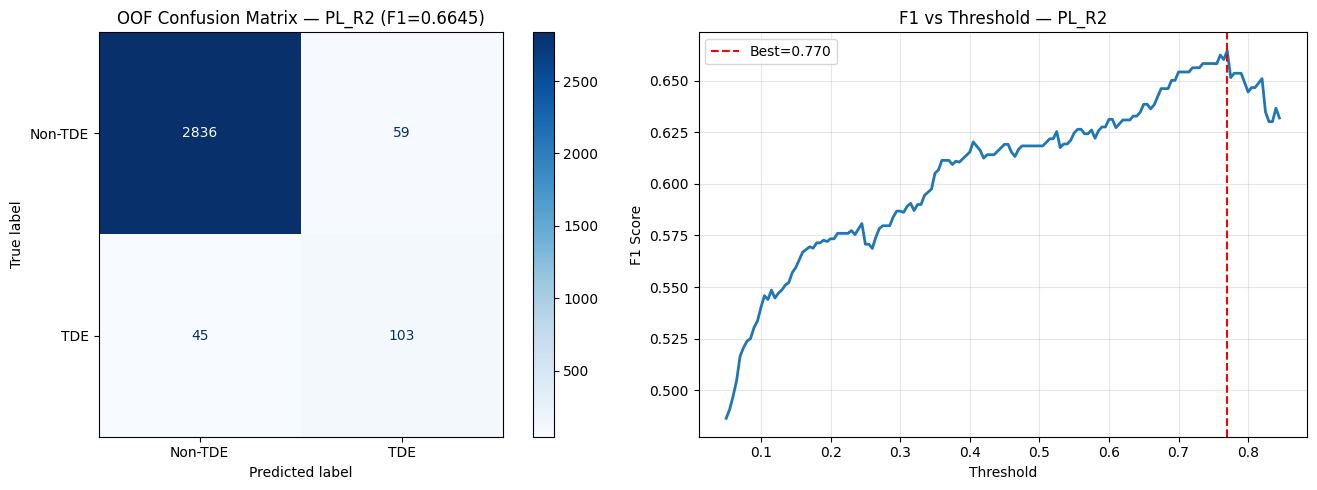


Individual model OOF F1 scores:
  LightGBM            : F1=0.6128 @ threshold=0.695
  XGBoost             : F1=0.6219 @ threshold=0.845
  CatBoost            : F1=0.5663 @ threshold=0.635

Model prediction correlations:
          LightGBM  XGBoost  CatBoost
LightGBM     1.000    0.954     0.733
XGBoost      0.954    1.000     0.761
CatBoost     0.733    0.761     1.000


In [15]:
# Classification report & confusion matrix
oof_pred = (best_oof >= best_thr).astype(int)
print(f"Using: {best_name} (threshold={best_thr:.3f})\n")
print(classification_report(y, oof_pred, target_names=["Non-TDE", "TDE"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y, oof_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-TDE", "TDE"])
disp.plot(ax=axes[0], cmap="Blues")
axes[0].set_title(f"OOF Confusion Matrix — {best_name} (F1={best_f1:.4f})")

# F1 vs threshold for best method
thresholds = np.arange(0.05, 0.85, 0.005)
f1s = [f1_score(y, (best_oof >= t).astype(int)) for t in thresholds]
axes[1].plot(thresholds, f1s, linewidth=2)
axes[1].axvline(best_thr, color="red", linestyle="--", label=f"Best={best_thr:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title(f"F1 vs Threshold — {best_name}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-model comparison
print("\nIndividual model OOF F1 scores:")
print("=" * 55)
for i, name in enumerate(model_names):
    thrs = np.arange(0.05, 0.85, 0.005)
    f1s = [f1_score(y, (oof_preds[:, i] >= t).astype(int)) for t in thrs]
    best_idx = np.argmax(f1s)
    print(f"  {name:20s}: F1={f1s[best_idx]:.4f} @ threshold={thrs[best_idx]:.3f}")

# Correlation
print(f"\nModel prediction correlations:")
corr_df = pd.DataFrame(oof_preds, columns=model_names).corr()
print(corr_df.round(3))

## 10. Feature Importance (Selected Features)

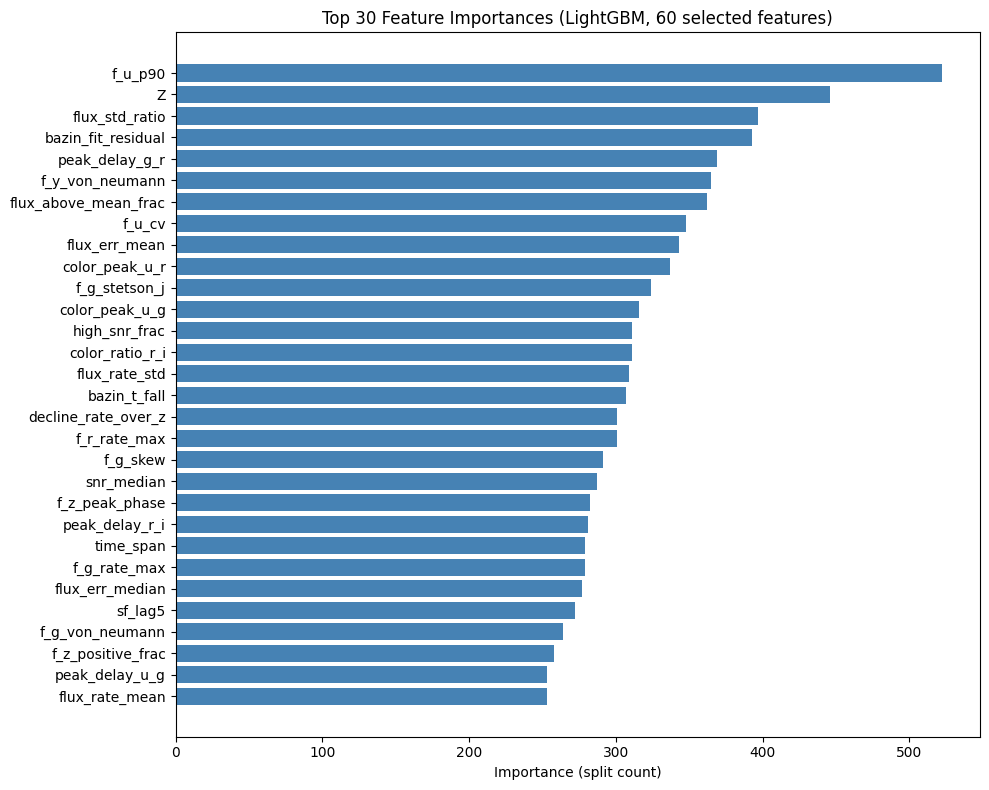

In [16]:
lgb_full = lgb.LGBMClassifier(**{**lgb_params, "n_estimators": 1500})
lgb_full.fit(X, y)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgb_full.feature_importances_
}).sort_values("importance", ascending=False)

top_n = min(30, len(feature_cols))
top_feats = importance.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), top_feats["importance"].values[::-1], color="steelblue")
plt.yticks(range(top_n), top_feats["feature"].values[::-1])
plt.xlabel("Importance (split count)")
plt.title(f"Top {top_n} Feature Importances (LightGBM, {len(feature_cols)} selected features)")
plt.tight_layout()
plt.show()

## 11. Generate Submissions

Save the best candidate + all alternatives for comparison.

In [19]:
OUT_DIR = "/Users/jackietan/Documents/workshop/academic/csc753m/kaggle_project/mallorn-astronomical-classification-challenge"

# Primary submission — best candidate
submission = pd.DataFrame({
    "object_id": test_log["object_id"],
    "prediction": (best_test_pred >= best_thr).astype(int),
})

# Sanity checks
sample = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert list(submission.columns) == list(sample.columns), "Column mismatch!"
assert len(submission) == len(sample), "Row count mismatch!"

print(f"Best method: {best_name}")
print(f"Threshold: {best_thr:.3f}")
print(f"OOF F1: {best_f1:.4f}")
print(f"\nSubmission shape: {submission.shape}")
print(f"Predicted TDEs: {submission['prediction'].sum()} / {len(submission)} ({submission['prediction'].mean():.2%})")
print(f"\nPrediction distribution:")
print(submission["prediction"].value_counts())

submission.to_csv(os.path.join(OUT_DIR, "submission_v3.csv"), index=False)
print(f"\nSaved to {os.path.join(OUT_DIR, 'submission_v3.csv')}")

# Save all alternative submissions
print("\n--- Alternative submissions ---")
for name, f1_val, thr, _, test_pred in candidates:
    sub = pd.DataFrame({
        "object_id": test_log["object_id"],
        "prediction": (test_pred >= thr).astype(int),
    })
    fname = f"submission_v3_{name}.csv"
    sub.to_csv(os.path.join(OUT_DIR, fname), index=False)
    print(f"{fname}: {sub['prediction'].sum()} TDEs predicted (OOF F1={f1_val:.4f}, thr={thr:.3f})")

print("\nDone! Try submitting each to see which generalizes best.")
submission.head(10)

Best method: PL_R2
Threshold: 0.770
OOF F1: 0.6645

Submission shape: (7135, 2)
Predicted TDEs: 363 / 7135 (5.09%)

Prediction distribution:
prediction
0    6772
1     363
Name: count, dtype: int64

Saved to /Users/jackietan/Documents/workshop/academic/csc753m/kaggle_project/mallorn-astronomical-classification-challenge/submission_v3.csv

--- Alternative submissions ---
submission_v3_PL_R2.csv: 363 TDEs predicted (OOF F1=0.6645, thr=0.770)
submission_v3_PL_R1.csv: 349 TDEs predicted (OOF F1=0.6485, thr=0.730)
submission_v3_XGBoost.csv: 318 TDEs predicted (OOF F1=0.6219, thr=0.845)
submission_v3_base.csv: 390 TDEs predicted (OOF F1=0.6209, thr=0.630)
submission_v3_base_ncv.csv: 390 TDEs predicted (OOF F1=0.6209, thr=0.630)
submission_v3_LightGBM.csv: 332 TDEs predicted (OOF F1=0.6128, thr=0.695)
submission_v3_CatBoost.csv: 307 TDEs predicted (OOF F1=0.5663, thr=0.635)

Done! Try submitting each to see which generalizes best.


,object_id,prediction
0,Eluwaith_Mithrim_nothrim,0
1,Eru_heledir_archam,0
2,Gonhir_anann_fuin,0
3,Gwathuirim_haradrim_tegilbor,0
4,achas_minai_maen,0
5,adab_fae_gath,0
6,adel_draug_gaur,0
7,aderthad_cuil_galadhrim,0
8,aegas_laug_ithildin,0
9,aegas_mereth_law,0
